# OpenHealth Price Transparency: Comprehensive Professional & Policy Briefing

This analysis evaluates healthcare market efficiency by combining **Econometric Skewness**, **Market Volatility**, and **Public Health Price Equity** metrics.

### Core Analysis Framework:
1.  **Skewness & Central Tendency:** Analyzing if outliers are driving mean inflation.
2.  **Price Volatility (CV):** Measuring the fragmentation and unpredictability of the market.
3.  **Negotiation Efficiency:** Tracking the gap between 'Sticker Prices' and Real Negotiated Rates.
4.  **The Price Multiplier:** Quantifying the 'Lottery Factor' (Price Irrationality) across procedures.

In [1]:
%matplotlib inline
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

BASE_URL = "http://localhost:3001/api/v1/transparency"
API_KEY = "AI4H2-PUBLIC-2023-BETA"

PROCEDURE_MAP = {
    "CPT:70551": "MRI Brain (without contrast)",
    "CPT:45378": "Colonoscopy",
    "DRG:871": "Sepsis (with Major CC)",
    "DRG:470": "Knee or Hip Replacement",
    "DRG:193": "Pneumonia (with Major CC)"
}

def fetch_data(pid):
    try:
        r = requests.get(BASE_URL, headers={"x-api-key": API_KEY}, params={"procedureId": pid})
        df = pd.DataFrame(r.json()["data"])
        if not df.empty:
            df['procedure_name'] = PROCEDURE_MAP.get(pid, pid)
            # Professional Metric: Negotiation Ratio (% of Sticker Price)
            df['negotiation_ratio'] = (df['avg_allowed'] / df['avg_charge']) * 100
        return df
    except:
        return pd.DataFrame()

full_df = pd.concat([fetch_data(pid) for pid in PROCEDURE_MAP.keys()], ignore_index=True)

## 1. Market Coverage & Skewness Analysis
We compare **Mean vs. Median**. If the Mean is significantly higher than the Median (Ratio > 1.0), the market is "Right-Skewed," meaning a few providers are charging exponentially more than the rest of the market.

### Market Skewness Report (Mean/Median Ratio)


source_year,2018,2019,2020,2021,2022,2023
procedure_name,,,,,,
Colonoscopy,0.99,1.00,1.01,0.99,0.99,1.01
Knee or Hip Replacement,1.06,1.06,1.05,1.07,1.12,1.12
MRI Brain (without contrast),1.01,1.01,1.01,1.01,1.01,1.01
Pneumonia (with Major CC),1.08,1.12,1.11,1.09,1.12,1.12
Sepsis (with Major CC),1.12,1.12,1.10,1.12,1.14,1.14


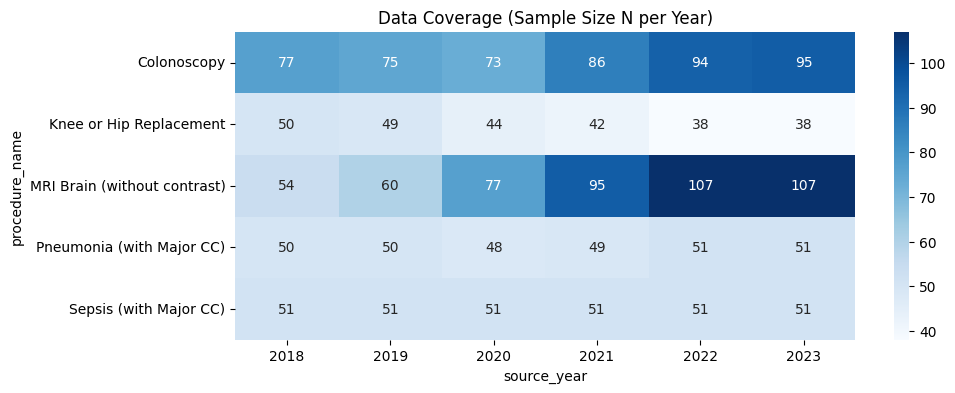

In [2]:
if not full_df.empty:
    # Coverage and Central Tendency Summary
    summary = full_df.groupby(['procedure_name', 'source_year'])['avg_allowed'].agg(['count', 'mean', 'median']).reset_index()
    summary['skew_factor'] = (summary['mean'] / summary['median']).round(2)
    
    print("### Market Skewness Report (Mean/Median Ratio)")
    display(summary.pivot(index='procedure_name', columns='source_year', values='skew_factor'))
    
    plt.figure(figsize=(10, 4))
    sns.heatmap(full_df.groupby(['procedure_name', 'source_year']).size().unstack(fill_value=0), annot=True, fmt="d", cmap="Blues")
    plt.title("Data Coverage (Sample Size N per Year)")
    plt.show()

## 2. Temporal Volatility: The 'Market Chaos' Index
We use the **Coefficient of Variation (CV)** ($StdDev / Mean$) to measure price dispersion. An increasing CV indicates that prices are becoming **more fragmented and less predictable** over time.

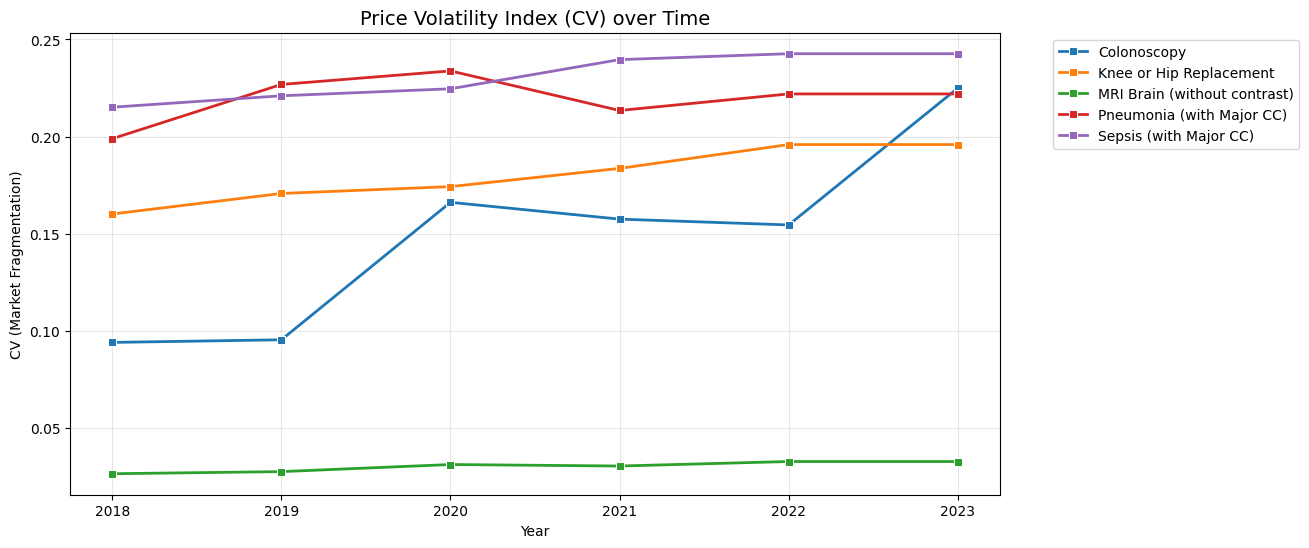

In [3]:
if not full_df.empty:
    cv_df = full_df.groupby(['procedure_name', 'source_year'])['avg_allowed'].apply(lambda x: x.std() / x.mean()).reset_index()
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=cv_df, x='source_year', y='avg_allowed', hue='procedure_name', marker='s', linewidth=2)
    plt.title("Price Volatility Index (CV) over Time", fontsize=14)
    plt.ylabel("CV (Market Fragmentation)")
    plt.xlabel("Year")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

## 3. Negotiation Efficiency Trend
This tracks the **Real Negotiated Price as a % of the Sticker Price (Gross Charge)**. A declining trend indicates that list prices are inflating significantly faster than what insurers actually pay.

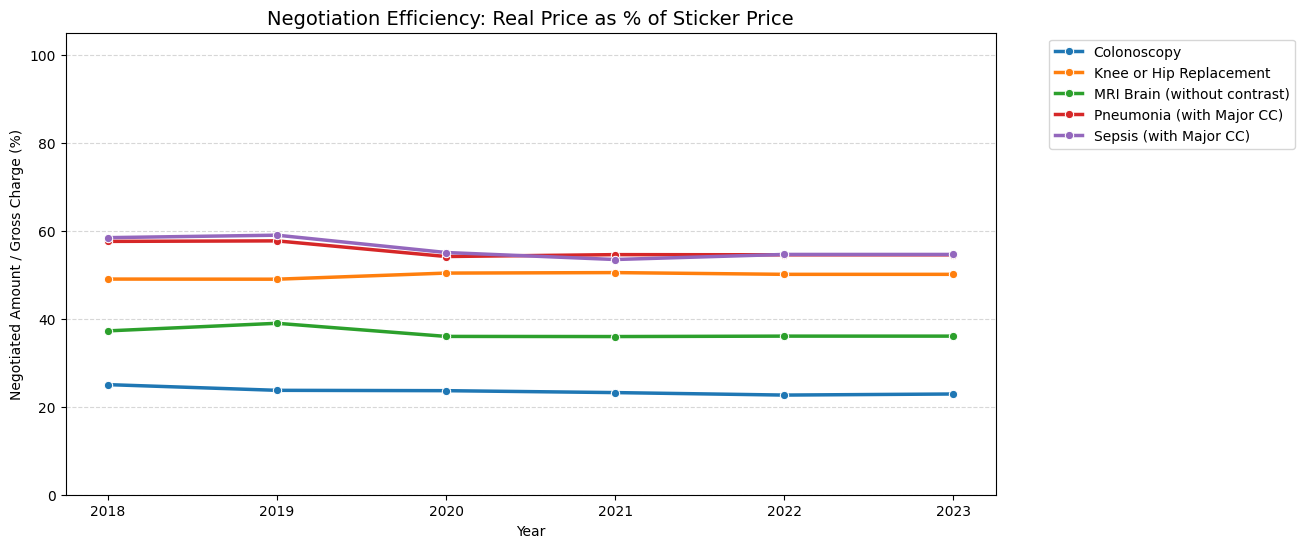

In [4]:
if not full_df.empty:
    ratio_trend = full_df.groupby(['procedure_name', 'source_year'])['negotiation_ratio'].mean().reset_index()
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=ratio_trend, x='source_year', y='negotiation_ratio', hue='procedure_name', marker='o', linewidth=2.5)
    plt.title("Negotiation Efficiency: Real Price as % of Sticker Price", fontsize=14)
    plt.ylabel("Negotiated Amount / Gross Charge (%)")
    plt.xlabel("Year")
    plt.ylim(0, 105)
    plt.grid(True, axis='y', ls='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

## 4. Market Irrationality Index (The Price Multiplier)
From a Public Health perspective, we measure the **Lottery Factor** ($P90/P10$). 

**Interpretation:** A multiplier of 5x means the most expensive hospital costs 500% more than the most affordable hospital for the **identical procedure** in the same market.

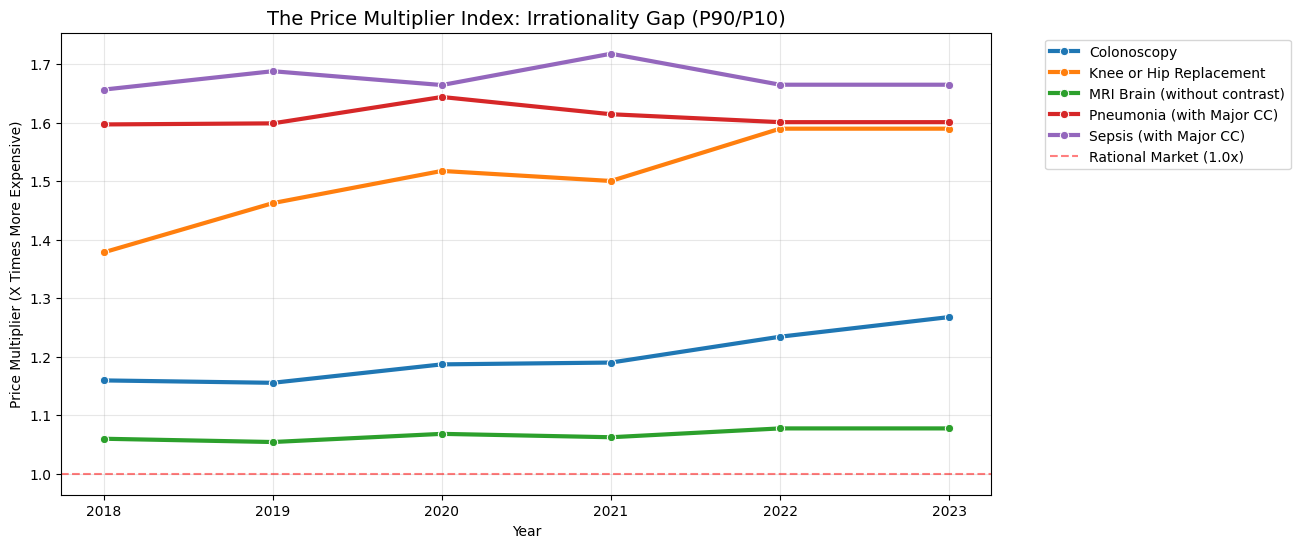

In [5]:
if not full_df.empty:
    # Calculate 10th and 90th percentiles
    mult_df = full_df.groupby(['procedure_name', 'source_year'])['avg_allowed'].agg([lambda x: x.quantile(0.10), lambda x: x.quantile(0.90)]).reset_index()
    mult_df.columns = ['Procedure', 'Year', 'P10', 'P90']
    
    # The Multiplier Index
    mult_df['multiplier'] = mult_df['P90'] / mult_df['P10']
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=mult_df, x='Year', y='multiplier', hue='Procedure', marker='o', linewidth=3)
    plt.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Rational Market (1.0x)')
    
    plt.title("The Price Multiplier Index: Irrationality Gap (P90/P10)", fontsize=14)
    plt.ylabel("Price Multiplier (X Times More Expensive)")
    plt.xlabel("Year")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()